
Training MLP with MAE loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0538 - val_loss: 0.0499
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 888us/step - loss: 0.0402 - val_loss: 0.0493
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0352 - val_loss: 0.0479
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 934us/step - loss: 0.0364 - val_loss: 0.0475
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 925us/step - loss: 0.0329 - val_loss: 0.0473
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step - loss: 0.0323 - val_loss: 0.0472
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0287 - val_loss: 0.0471
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0351 - val_loss: 0.0470
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0306 - val_loss: 0.0471
Epoch 10/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 985us/step - loss: 0.0264 - val_loss: 0.0469
Epoch 11/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 959us/step - loss: 0.0279 - val_loss: 0.0472
Epoch 12/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 884us/step - loss: 0.0322 - val

Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


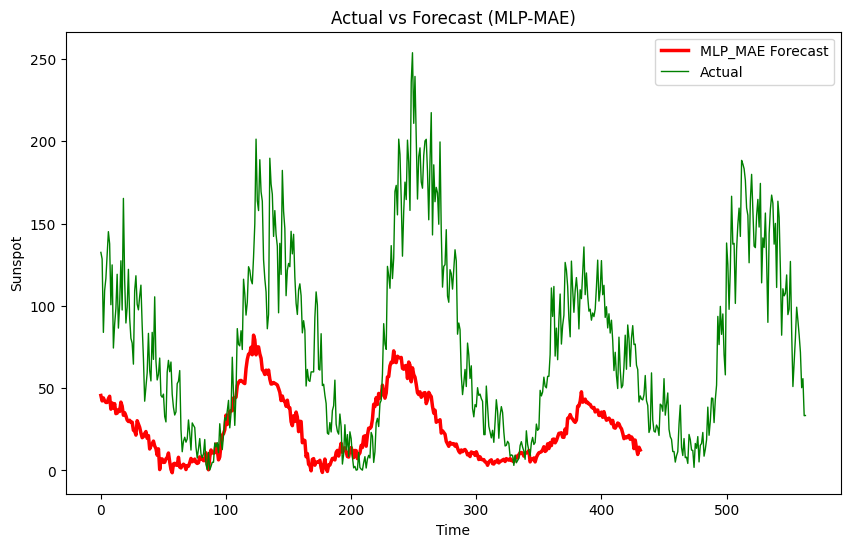


Evaluation Metrics
MSE   : 4883.629131399542
RMSE  : 69.88296739120014
NRMSE: 0.2755637515425873
MAE   : 55.22783169396549
SMAPE : 101.85038715668998
MASE  : 3.7294469972736586


In [1]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 3. TRAIN MODEL (MAE LOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP with MAE loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=tf.keras.losses.MeanAbsoluteError()
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 4. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)
    model = tf.keras.models.load_model(cfg['model_path'])

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 5. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)
    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 6. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_MAE Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-MAE)")
    plt.legend()
    plt.show()


# =========================================================
# 7. METRICS
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 8. CONFIGURATION (ALL PATHS FILLED)
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_10\x_train_sunspot_full_10.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_10\y_train_sunspot_full_10.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV (FOR INVERSE SCALING + PLOT)
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_mae_sunspot_final_10.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_mae_daily_sunspot_loss_history_10.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mae_sunspot_10.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mae_sunspot_10.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mae_sunspot_rescaled_10.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mae_sunspot_rescaled_10.csv"
}


# =========================================================
# 9. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP with MSE loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0187 - val_loss: 0.0157
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0102 - val_loss: 0.0146
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 925us/step - loss: 0.0100 - val_loss: 0.0150
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - loss: 0.0099 - val_loss: 0.0141
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0085 - val_loss: 0.0144
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 965us/step - loss: 0.0072 - val_loss: 0.0157
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0054 - val_loss: 0.0149
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 659us/step - loss: 0.0048 - val_loss: 0.0148
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 814us/step - loss: 0.0043 - val_loss: 0.0153
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 4.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


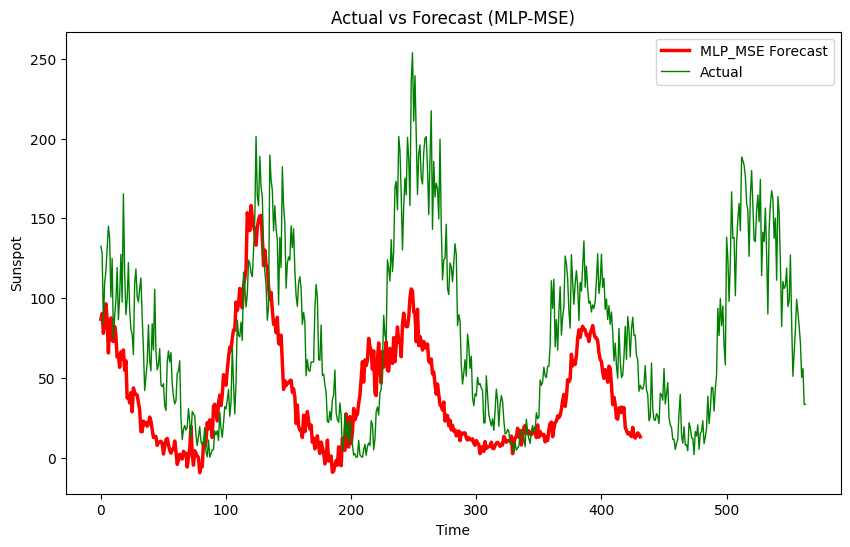


Evaluation Metrics
MSE   : 2843.495286794459
RMSE  : 53.32443423792191
NRMSE: 0.21026985109590657
MAE   : 43.66490456504818
SMAPE : 87.24741399947581
MASE  : 2.9486210524928738


In [2]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 3. TRAIN MODEL (MSE LOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP with MSE loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=tf.keras.losses.MeanSquaredError()
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 4. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)
    model = tf.keras.models.load_model(cfg['model_path'])

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 5. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)
    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 6. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_MSE Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-MSE)")
    plt.legend()
    plt.show()


# =========================================================
# 7. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 8. CONFIGURATION (MSE NAMING)
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_10\x_train_sunspot_full_10.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_10\y_train_sunspot_full_10.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_mse_sunspot_final_10.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_mse_sunspot_loss_history_10.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mse_sunspot_10.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mse_sunspot_10.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mse_sunspot_rescaled_10.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mse_sunspot_rescaled_10.csv"
}


# =========================================================
# 9. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP with Huber loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0036 - val_loss: 0.0031
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0026 - val_loss: 0.0030
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0022 - val_loss: 0.0030
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0017 - val_loss: 0.0030
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 721us/step - loss: 0.0020 - val_loss: 0.0030
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step - loss: 0.0021 - val_loss: 0.0030
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


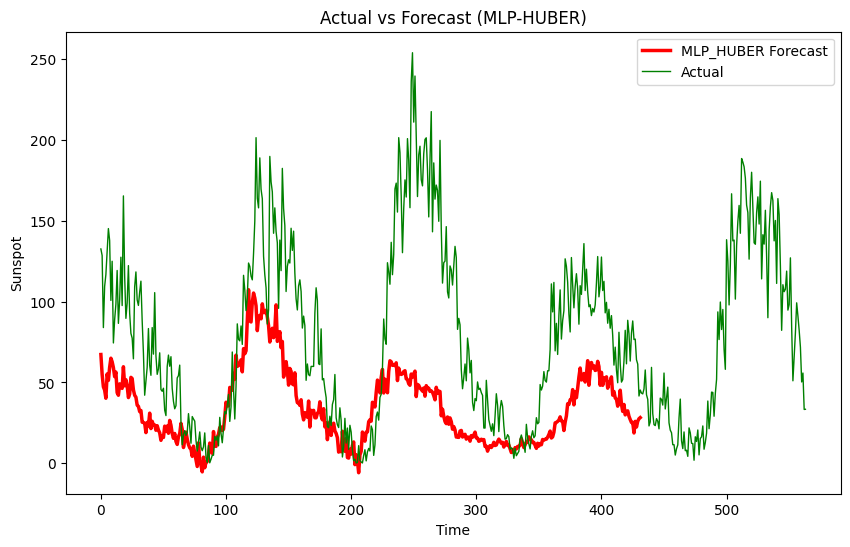


Evaluation Metrics
MSE   : 3702.524983576796
RMSE  : 60.8483770003506
NRMSE: 0.23993839511179257
MAE   : 47.03869357683009
SMAPE : 77.62234299568381
MASE  : 3.176447619524288


In [3]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 3. HUBER LOSS (CUSTOM DEFINITION)
# =========================================================
def huber_loss(delta=1.0):
    def loss(y_true, y_pred):
        error = y_true - y_pred
        abs_error = tf.abs(error)
        quadratic = tf.minimum(abs_error, delta)
        linear = abs_error - quadratic
        return tf.reduce_mean(0.5 * tf.square(quadratic) + delta * linear)
    return loss


# =========================================================
# 4. TRAIN MODEL (HUBER LOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP with Huber loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=huber_loss(delta=cfg['huber_delta'])
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)
    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={'loss': huber_loss(cfg['huber_delta'])}
    )

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)
    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_HUBER Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-HUBER)")
    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (HUBER NAMING)
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    'huber_delta': 0.100,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_10\x_train_sunspot_full_10.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_10\y_train_sunspot_full_10.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_huber_sunspot_final_10.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_huber_sunspot_loss_history_10.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_huber_sunspot_10.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_huber_sunspot_10.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_huber_sunspot_rescaled_10.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_huber_sunspot_rescaled_10.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP with Log-Cosh loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0072 - val_loss: 0.0072
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0055 - val_loss: 0.0075
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0047 - val_loss: 0.0073
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0040 - val_loss: 0.0073
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 860us/step - loss: 0.0035 - val_loss: 0.0074
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step - loss: 0.0029 - val_loss: 0.0076
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


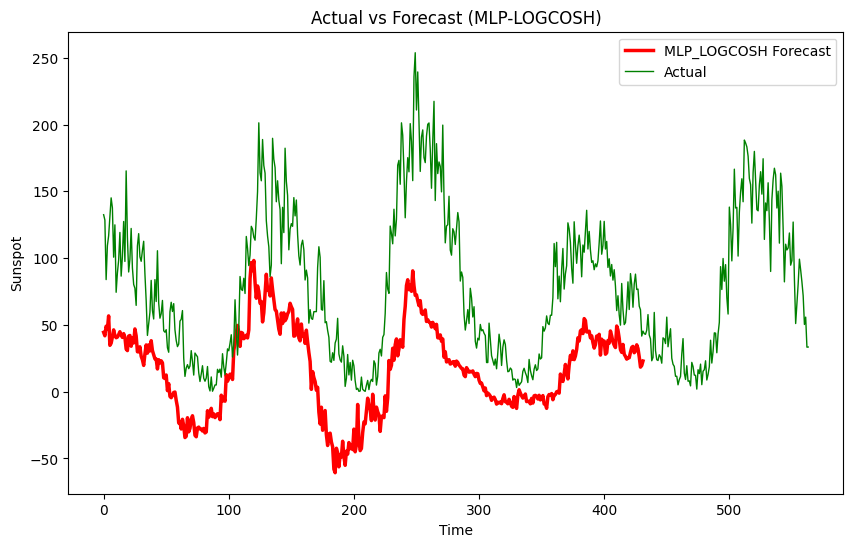


Evaluation Metrics
MSE   : 5291.22918670969
RMSE  : 72.74083575756943
NRMSE: 0.28683294857085734
MAE   : 62.96578764438983
SMAPE : 136.87860962468434
MASE  : 4.251978766115474


In [4]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 3. LOG-COSH LOSS (CUSTOM DEFINITION)
# =========================================================
def logcosh_loss(y_true, y_pred):
    return tf.reduce_mean(tf.math.log(tf.cosh(y_pred - y_true)))


# =========================================================
# 4. TRAIN MODEL (LOG-COSH LOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP with Log-Cosh loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=logcosh_loss
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={'logcosh_loss': logcosh_loss}
    )

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)
    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_LOGCOSH Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-LOGCOSH)")
    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (LOG-COSH NAMING)
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_10\x_train_sunspot_full_10.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_10\y_train_sunspot_full_10.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_logcosh_sunspot_final_10.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_logcosh_sunspot_loss_history_10.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_logcosh_sunspot_10.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_logcosh_sunspot_10.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_logcosh_sunspot_rescaled_10.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_logcosh_sunspot_rescaled_10.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP using RoBoSS loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.8373e-04 - val_loss: 8.3342e-04
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.5733e-04 - val_loss: 8.1669e-04
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.9122e-04 - val_loss: 8.5773e-04
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.5875e-04 - val_loss: 9.3094e-04
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.3492e-04 - val_loss: 9.5989e-04
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.4292e-04 - val_loss: 9.4733e-04
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


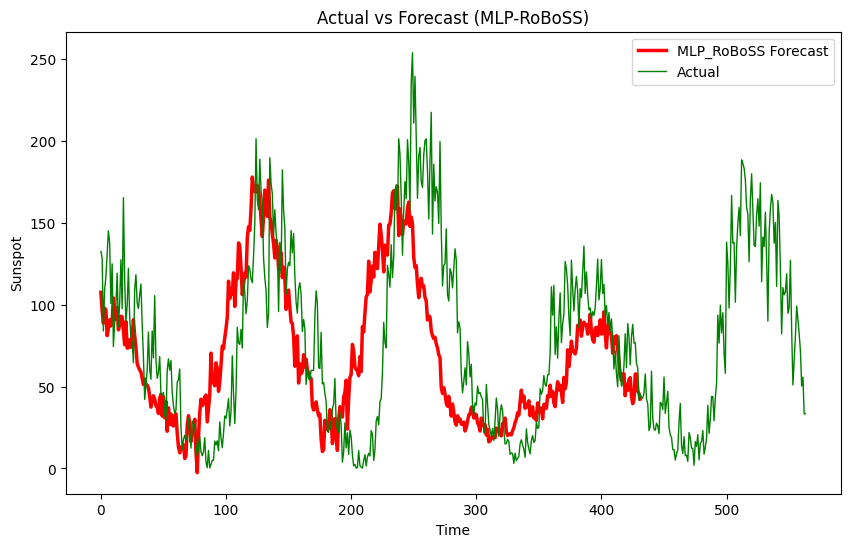


Evaluation Metrics
MSE   : 1942.8181046452632
RMSE  : 44.077410366822406
NRMSE: 0.1738068232130221
MAE   : 34.43200983851911
SMAPE : 54.934953702876406
MASE  : 2.3251384630476672


In [5]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. ROBOSS LOSS
# =========================================================
def roboss_nn_loss(y_true, y_pred, a, epsilon, lam):
    u = tf.abs(y_true - y_pred)
    val = a * tf.sqrt(tf.square(u) + epsilon) - a * tf.sqrt(epsilon)
    loss_val = lam * (1 - (val + 1) * tf.exp(-val))
    return tf.reduce_mean(loss_val)


# =========================================================
# 2. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 3. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 4. TRAIN MODEL (ROBOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP using RoBoSS loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    def dynamic_roboss_loss(y_true, y_pred):
        return roboss_nn_loss(y_true, y_pred, cfg['a'], cfg['epsilon'], cfg['lam'])

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=dynamic_roboss_loss
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)

    def dynamic_roboss_loss(y_true, y_pred):
        return roboss_nn_loss(y_true, y_pred, cfg['a'], cfg['epsilon'], cfg['lam'])

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={
            'dynamic_roboss_loss': dynamic_roboss_loss,
            'roboss_nn_loss': roboss_nn_loss
        }
    )

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)

    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_RoBoSS Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-RoBoSS)")
    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    'a': 1.098,
    'epsilon': 0.042,
    'lam': 0.347,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_10\x_train_sunspot_full_10.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_10\y_train_sunspot_full_10.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV (FOR INVERSE SCALING + PLOT)
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_robos_sunspot_final_10.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_robos_daily_sunspot_loss_history_10.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_robos_sunspot_10.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_robos_sunspot_10.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_robos_sunspot_rescaled_10.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_robos_sunspot_rescaled_10.csv"
}




# =========================================================
# 10. RUN COMPLETE PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP with Cauchy loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0018 - val_loss: 0.0014
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 964us/step - loss: 0.0011 - val_loss: 0.0014
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.3217e-04 - val_loss: 0.0013
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.5654e-04 - val_loss: 0.0013
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step - loss: 8.7883e-04 - val_loss: 0.0013
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.8475e-04 - val_loss: 0.0013
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 3.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


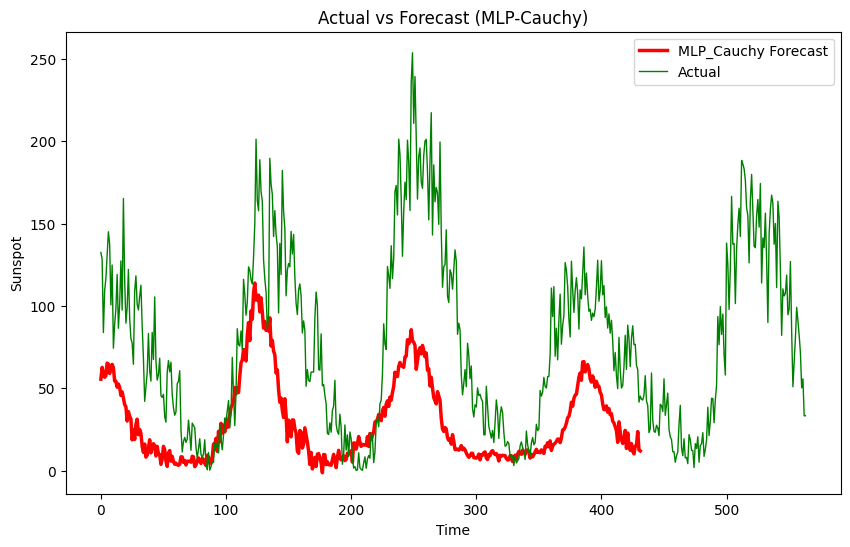


Evaluation Metrics
MSE   : 4128.577704337684
RMSE  : 64.25400924718771
NRMSE : 0.2533675443501092
MAE   : 51.18385621860054
SMAPE : 93.29962251552003
MASE  : 3.456363812019872


In [6]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):

    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x,
        y,
        test_size=validation_split,
        random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices(
        (x_train, y_train)
    ).shuffle(
        len(x_train)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    val_data = tf.data.Dataset.from_tensor_slices(
        (x_val, y_val)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():

    seq_size = 132

    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])

    return model


# =========================================================
# 3. CAUCHY LOSS
# =========================================================
def cauchy_loss(c=1.0):

    def loss(y_true, y_pred):

        error = y_true - y_pred

        loss_value = (
            (c ** 2) / 2.0
        ) * tf.math.log(
            1.0 + tf.square(error) / (c ** 2)
        )

        return tf.reduce_mean(loss_value)

    return loss


# =========================================================
# 4. TRAIN MODEL (CAUCHY LOSS)
# =========================================================
def train_model(cfg):

    print("\nTraining MLP with Cauchy loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            cfg['learning_rate'],
            amsgrad=True
        ),
        loss=cauchy_loss(
            c=cfg['cauchy_c']
        )
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(
        cfg['model_path']
    )

    pd.DataFrame(
        history.history
    ).to_csv(
        cfg['loss_path'],
        index=False
    )

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):

    print("Generating forecasts")

    x_test = np.load(
        cfg['x_test_path']
    ).reshape(-1, 132, 1)

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={
            'loss': cauchy_loss(
                cfg['cauchy_c']
            )
        }
    )

    y_hat = model.predict(x_test)

    np.save(
        cfg['forecast_npy'],
        y_hat
    )

    np.savetxt(
        cfg['forecast_csv'],
        y_hat,
        delimiter=','
    )


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):

    df_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_hat = pd.read_csv(
        cfg['forecast_csv'],
        header=None
    ).values.flatten()

    scaler = MinMaxScaler()

    inverse_preds = []

    for i in range(
        len(df_actual) - 132
    ):

        window = np.array(
            df_actual.iloc[i:i+132]
        ).reshape(-1, 1)

        scaler.fit(window)

        inverse_preds.append(
            scaler.inverse_transform(
                [[y_hat[i]]]
            )[0][0]
        )

    inverse_preds = np.array(
        inverse_preds
    )

    np.save(
        cfg['forecast_rescaled_npy'],
        inverse_preds
    )

    np.savetxt(
        cfg['forecast_rescaled_csv'],
        inverse_preds,
        delimiter=','
    )


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):

    y_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_pred = pd.read_csv(
        cfg['forecast_rescaled_csv'],
        header=None
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        y_pred,
        label="MLP_Cauchy Forecast",
        color='red',
        linewidth=2.5
    )

    plt.plot(
        y_actual,
        label="Actual",
        color='green',
        linewidth=1
    )

    plt.xlabel("Time")
    plt.ylabel("Sunspot")

    plt.title(
        "Actual vs Forecast (MLP-Cauchy)"
    )

    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):

    return np.mean(
        200 * np.abs(yhat - y) /
        (np.abs(y) + np.abs(yhat))
    )


def mase(y, yhat):

    return np.mean(
        np.abs(y - yhat)
    ) / np.mean(
        np.abs(y[1:] - y[:-1])
    )


def compute_metrics(cfg):

    y_test = np.load(
        cfg['y_test_npy']
    )

    y_pred = np.load(
        cfg['forecast_rescaled_npy']
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    nrmse = rmse / (
        np.max(y_test) -
        np.min(y_test)
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    print("\nEvaluation Metrics")

    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE :", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (CAUCHY NAMING)
# =========================================================
cfg = {

    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # Cauchy parameter
    'cauchy_c': 0.101,

    # TRAIN / TEST DATA
    'x_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_10\x_train_sunspot_full_10.npy",

    'y_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_10\y_train_sunspot_full_10.npy",

    'x_test_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",

    'y_test_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_cauchy_sunspot_final_10.h5",

    'loss_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_cauchy_sunspot_loss_history_10.csv",

    # FORECASTS
    'forecast_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_cauchy_sunspot_10.npy",

    'forecast_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_cauchy_sunspot_10.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_cauchy_sunspot_rescaled_10.npy",

    'forecast_rescaled_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_cauchy_sunspot_rescaled_10.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)


Training MLP with Tukey's Biweight loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.8701e-04 - val_loss: 4.9973e-04
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step - loss: 3.2646e-04 - val_loss: 4.1465e-04
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.6239e-04 - val_loss: 3.9313e-04
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.2771e-04 - val_loss: 3.8021e-04
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.8489e-04 - val_loss: 3.7846e-04
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step - loss: 1.7472e-04 - val_loss: 3.8068e-04
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.7458e-04 - val_loss: 3.8050e-04
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.5434e-04 - val_loss: 3.7295e-04
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 3.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


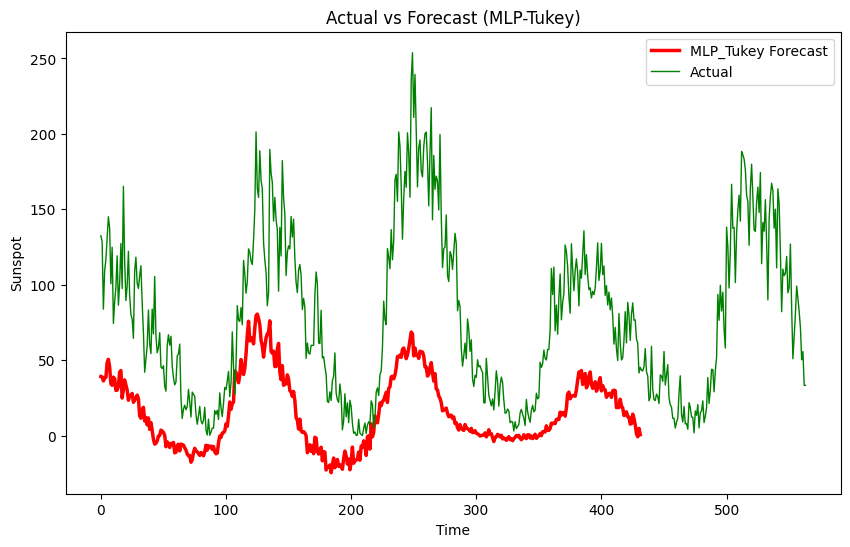


Evaluation Metrics
MSE   : 5689.114735540485
RMSE  : 75.42622047763287
NRMSE : 0.29742200503798444
MAE   : 64.31305694532709
SMAPE : 150.643988873466
MASE  : 4.342957703632742


In [8]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):

    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x,
        y,
        test_size=validation_split,
        random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices(
        (x_train, y_train)
    ).shuffle(
        len(x_train)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    val_data = tf.data.Dataset.from_tensor_slices(
        (x_val, y_val)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():

    seq_size = 132

    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])

    return model


# =========================================================
# 3. TUKEY'S BIWEIGHT LOSS
# =========================================================
def tukey_biweight_loss(c=1.0):

    def loss(y_true, y_pred):

        error = y_true - y_pred

        abs_error = tf.abs(error)

        # Region where |r| <= c
        inside = abs_error <= c

        # Tukey biweight expression
        scaled_error = error / c

        inside_loss = (
            (c ** 2) / 6.0
        ) * (
            1.0 -
            tf.pow(
                1.0 - tf.square(scaled_error),
                3
            )
        )

        # Constant loss for |r| > c
        outside_loss = (
            (c ** 2) / 6.0
        ) * tf.ones_like(error)

        loss_value = tf.where(
            inside,
            inside_loss,
            outside_loss
        )

        return tf.reduce_mean(loss_value)

    return loss


# =========================================================
# 4. TRAIN MODEL (TUKEY'S BIWEIGHT LOSS)
# =========================================================
def train_model(cfg):

    print("\nTraining MLP with Tukey's Biweight loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            cfg['learning_rate'],
            amsgrad=True
        ),
        loss=tukey_biweight_loss(
            c=cfg['tukey_c']
        )
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(
        cfg['model_path']
    )

    pd.DataFrame(
        history.history
    ).to_csv(
        cfg['loss_path'],
        index=False
    )

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):

    print("Generating forecasts")

    x_test = np.load(
        cfg['x_test_path']
    ).reshape(-1, 132, 1)

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={
            'loss': tukey_biweight_loss(
                cfg['tukey_c']
            )
        }
    )

    y_hat = model.predict(x_test)

    np.save(
        cfg['forecast_npy'],
        y_hat
    )

    np.savetxt(
        cfg['forecast_csv'],
        y_hat,
        delimiter=','
    )


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):

    df_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_hat = pd.read_csv(
        cfg['forecast_csv'],
        header=None
    ).values.flatten()

    scaler = MinMaxScaler()

    inverse_preds = []

    for i in range(
        len(df_actual) - 132
    ):

        window = np.array(
            df_actual.iloc[i:i+132]
        ).reshape(-1, 1)

        scaler.fit(window)

        inverse_preds.append(
            scaler.inverse_transform(
                [[y_hat[i]]]
            )[0][0]
        )

    inverse_preds = np.array(
        inverse_preds
    )

    np.save(
        cfg['forecast_rescaled_npy'],
        inverse_preds
    )

    np.savetxt(
        cfg['forecast_rescaled_csv'],
        inverse_preds,
        delimiter=','
    )


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):

    y_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_pred = pd.read_csv(
        cfg['forecast_rescaled_csv'],
        header=None
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        y_pred,
        label="MLP_Tukey Forecast",
        color='red',
        linewidth=2.5
    )

    plt.plot(
        y_actual,
        label="Actual",
        color='green',
        linewidth=1
    )

    plt.xlabel("Time")
    plt.ylabel("Sunspot")

    plt.title(
        "Actual vs Forecast (MLP-Tukey)"
    )

    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):

    return np.mean(
        200 * np.abs(yhat - y) /
        (np.abs(y) + np.abs(yhat))
    )


def mase(y, yhat):

    return np.mean(
        np.abs(y - yhat)
    ) / np.mean(
        np.abs(y[1:] - y[:-1])
    )


def compute_metrics(cfg):

    y_test = np.load(
        cfg['y_test_npy']
    )

    y_pred = np.load(
        cfg['forecast_rescaled_npy']
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    nrmse = rmse / (
        np.max(y_test) -
        np.min(y_test)
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    print("\nEvaluation Metrics")

    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE :", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (TUKEY NAMING)
# =========================================================
cfg = {

    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # Tukey's Biweight parameter
    'tukey_c': 0.101,

    # TRAIN / TEST DATA
    'x_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_10\x_train_sunspot_full_10.npy",

    'y_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_10\y_train_sunspot_full_10.npy",

    'x_test_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",

    'y_test_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_tukey_sunspot_final_10.h5",

    'loss_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_tukey_sunspot_loss_history_10.csv",

    # FORECASTS
    'forecast_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_tukey_sunspot_10.npy",

    'forecast_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_tukey_sunspot_10.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_tukey_sunspot_rescaled_10.npy",

    'forecast_rescaled_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_tukey_sunspot_rescaled_10.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)


Training MLP with HawkEye loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.0862e-04 - val_loss: 5.6708e-04
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.3367e-04 - val_loss: 5.7454e-04
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.0427e-04 - val_loss: 5.6599e-04
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.6074e-04 - val_loss: 5.8920e-04
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.6255e-04 - val_loss: 5.9457e-04
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.5913e-04 - val_loss: 5.9931e-04
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


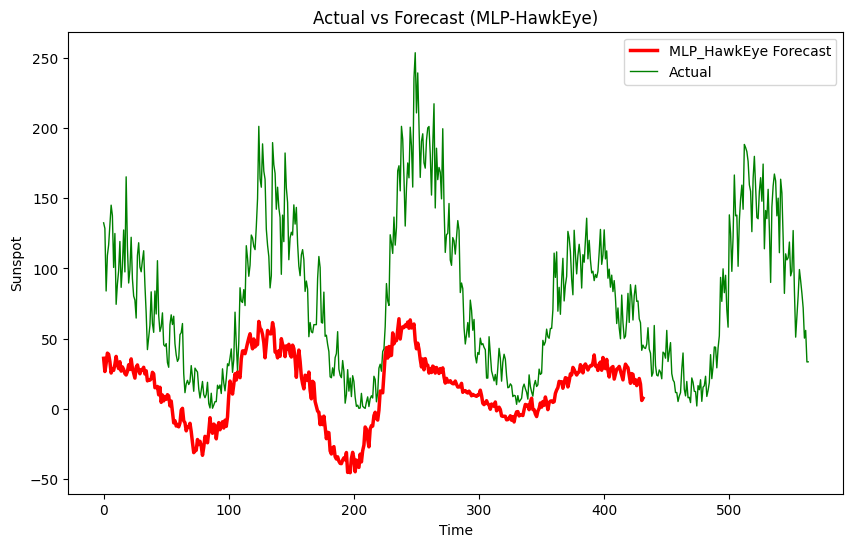


Evaluation Metrics
MSE   : 6058.436378865772
RMSE  : 77.83595813546444
NRMSE : 0.30692412513984396
MAE   : 66.04742677842238
SMAPE : 141.78696083254582
MASE  : 4.460076919937335


In [9]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):

    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x,
        y,
        test_size=validation_split,
        random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices(
        (x_train, y_train)
    ).shuffle(
        len(x_train)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    val_data = tf.data.Dataset.from_tensor_slices(
        (x_val, y_val)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():

    seq_size = 132

    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])

    return model


# =========================================================
# 3. HAWKEYE LOSS
# =========================================================
def hawkeye_loss(a=1.0, epsilon=0.02, lam=1.0):

    def loss(y_true, y_pred):

        # Residual
        r = y_true - y_pred

        # -------------------------------------------------
        # Left region: r <= -epsilon
        # -------------------------------------------------
        left_loss = lam * (
            1.0
            - (
                -a * (r + epsilon) + 1.0
            )
            * tf.exp(
                a * (r + epsilon)
            )
        )

        # -------------------------------------------------
        # Middle region: -epsilon < r < epsilon
        # -------------------------------------------------
        middle_loss = tf.zeros_like(r)

        # -------------------------------------------------
        # Right region: r >= epsilon
        # -------------------------------------------------
        right_loss = lam * (
            1.0
            - (
                a * (r - epsilon) + 1.0
            )
            * tf.exp(
                -a * (r - epsilon)
            )
        )

        # -------------------------------------------------
        # Piecewise HawkEye loss
        # -------------------------------------------------
        loss_value = tf.where(
            r <= -epsilon,
            left_loss,
            tf.where(
                r >= epsilon,
                right_loss,
                middle_loss
            )
        )

        return tf.reduce_mean(loss_value)

    return loss


# =========================================================
# 4. TRAIN MODEL (HAWKEYE LOSS)
# =========================================================
def train_model(cfg):

    print("\nTraining MLP with HawkEye loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            cfg['learning_rate'],
            amsgrad=True
        ),
        loss=hawkeye_loss(
            a=cfg['hawkeye_a'],
            epsilon=cfg['hawkeye_epsilon'],
            lam=cfg['hawkeye_lam']
        )
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(
        cfg['model_path']
    )

    pd.DataFrame(
        history.history
    ).to_csv(
        cfg['loss_path'],
        index=False
    )

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):

    print("Generating forecasts")

    x_test = np.load(
        cfg['x_test_path']
    ).reshape(-1, 132, 1)

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={
            'loss': hawkeye_loss(
                a=cfg['hawkeye_a'],
                epsilon=cfg['hawkeye_epsilon'],
                lam=cfg['hawkeye_lam']
            )
        }
    )

    y_hat = model.predict(x_test)

    np.save(
        cfg['forecast_npy'],
        y_hat
    )

    np.savetxt(
        cfg['forecast_csv'],
        y_hat,
        delimiter=','
    )


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):

    df_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_hat = pd.read_csv(
        cfg['forecast_csv'],
        header=None
    ).values.flatten()

    scaler = MinMaxScaler()

    inverse_preds = []

    for i in range(
        len(df_actual) - 132
    ):

        window = np.array(
            df_actual.iloc[i:i+132]
        ).reshape(-1, 1)

        scaler.fit(window)

        inverse_preds.append(
            scaler.inverse_transform(
                [[y_hat[i]]]
            )[0][0]
        )

    inverse_preds = np.array(
        inverse_preds
    )

    np.save(
        cfg['forecast_rescaled_npy'],
        inverse_preds
    )

    np.savetxt(
        cfg['forecast_rescaled_csv'],
        inverse_preds,
        delimiter=','
    )


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):

    y_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_pred = pd.read_csv(
        cfg['forecast_rescaled_csv'],
        header=None
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        y_pred,
        label="MLP_HawkEye Forecast",
        color='red',
        linewidth=2.5
    )

    plt.plot(
        y_actual,
        label="Actual",
        color='green',
        linewidth=1
    )

    plt.xlabel("Time")
    plt.ylabel("Sunspot")

    plt.title(
        "Actual vs Forecast (MLP-HawkEye)"
    )

    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):

    return np.mean(
        200 * np.abs(yhat - y) /
        (np.abs(y) + np.abs(yhat))
    )


def mase(y, yhat):

    return np.mean(
        np.abs(y - yhat)
    ) / np.mean(
        np.abs(y[1:] - y[:-1])
    )


def compute_metrics(cfg):

    y_test = np.load(
        cfg['y_test_npy']
    )

    y_pred = np.load(
        cfg['forecast_rescaled_npy']
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    nrmse = rmse / (
        np.max(y_test) -
        np.min(y_test)
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    print("\nEvaluation Metrics")

    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE :", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (HAWKEYE NAMING)
# =========================================================
cfg = {

    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # -----------------------------------------------------
    # HAWKEYE PARAMETERS
    # -----------------------------------------------------
    'hawkeye_a': 1.058,
    'hawkeye_epsilon': 0.028,
    'hawkeye_lam': 0.114,

    # -----------------------------------------------------
    # TRAIN / TEST DATA
    # -----------------------------------------------------
    'x_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_10\x_train_sunspot_full_10.npy",

    'y_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_10\y_train_sunspot_full_10.npy",

    'x_test_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",

    'y_test_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # -----------------------------------------------------
    # RAW TEST CSV
    # -----------------------------------------------------
    'actual_test_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # -----------------------------------------------------
    # MODEL & LOGS
    # -----------------------------------------------------
    'model_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_hawkeye_sunspot_final_10.h5",

    'loss_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_hawkeye_sunspot_loss_history_10.csv",

    # -----------------------------------------------------
    # FORECASTS
    # -----------------------------------------------------
    'forecast_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_hawkeye_sunspot_10.npy",

    'forecast_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_hawkeye_sunspot_10.csv",

    # -----------------------------------------------------
    # RESCALED FORECASTS
    # -----------------------------------------------------
    'forecast_rescaled_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_hawkeye_sunspot_rescaled_10.npy",

    'forecast_rescaled_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_hawkeye_sunspot_rescaled_10.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)